# Hierarchical Clustering
Is used in biology and also to automatically decide the number of clusters without user interaction.

It may start with all points in the same cluster and then separating the most disimilar.

It may also start with each point as its own cluster and then joining them together as they are close to each other. This is the most common and is called **Agglomerative**.

To display the result, a dendrogram is used. It is expensive to compute, but very helpful to see the cluster relaction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('../../jupyter_notebooks/DATA/cluster_mpg.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
 8   name          392 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 27.7 KB


In [3]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
model_year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0


In [4]:
df['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

Origin is a category feature, so we'll be building dummy variables for it. Since we are in unsupervised learning, there is no need to drop one of the dummies, there is no colinearity concern.

The model *name* is the observation key and they all are going to be different, so it will not be taken into the clustering process.

In [5]:
 df_dummies=pd.get_dummies(df.drop('name',axis=1))

In [6]:
df_dummies.info()

<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mpg            392 non-null    float64
 1   cylinders      392 non-null    int64  
 2   displacement   392 non-null    float64
 3   horsepower     392 non-null    float64
 4   weight         392 non-null    int64  
 5   acceleration   392 non-null    float64
 6   model_year     392 non-null    int64  
 7   origin_europe  392 non-null    bool   
 8   origin_japan   392 non-null    bool   
 9   origin_usa     392 non-null    bool   
dtypes: bool(3), float64(4), int64(3)
memory usage: 22.7 KB


In [10]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler=MinMaxScaler()

In [15]:
scaled_data=scaler.fit_transform(df_dummies)
scaled_data

array([[0.2393617 , 1.        , 0.61757106, ..., 0.        , 0.        ,
        1.        ],
       [0.15957447, 1.        , 0.72868217, ..., 0.        , 0.        ,
        1.        ],
       [0.2393617 , 1.        , 0.64599483, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.61170213, 0.2       , 0.17312661, ..., 0.        , 0.        ,
        1.        ],
       [0.50531915, 0.2       , 0.13436693, ..., 0.        , 0.        ,
        1.        ],
       [0.58510638, 0.2       , 0.13178295, ..., 0.        , 0.        ,
        1.        ]], shape=(392, 10))

Now, before proceeding, transform the scaled_data array into a DataFrame.

In [16]:
scaled_df=pd.DataFrame(scaled_data,columns=df_dummies.columns)
scaled_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,0.239362,1.0,0.617571,0.456522,0.536150,0.238095,0.0,0.0,0.0,1.0
1,0.159574,1.0,0.728682,0.646739,0.589736,0.208333,0.0,0.0,0.0,1.0
2,0.239362,1.0,0.645995,0.565217,0.516870,0.178571,0.0,0.0,0.0,1.0
3,0.186170,1.0,0.609819,0.565217,0.516019,0.238095,0.0,0.0,0.0,1.0
4,0.212766,1.0,0.604651,0.510870,0.520556,0.148810,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
387,0.478723,0.2,0.186047,0.217391,0.333711,0.452381,1.0,0.0,0.0,1.0
388,0.930851,0.2,0.074935,0.032609,0.146583,0.988095,1.0,1.0,0.0,0.0
389,0.611702,0.2,0.173127,0.206522,0.193365,0.214286,1.0,0.0,0.0,1.0
390,0.505319,0.2,0.134367,0.179348,0.286929,0.630952,1.0,0.0,0.0,1.0


<Axes: >

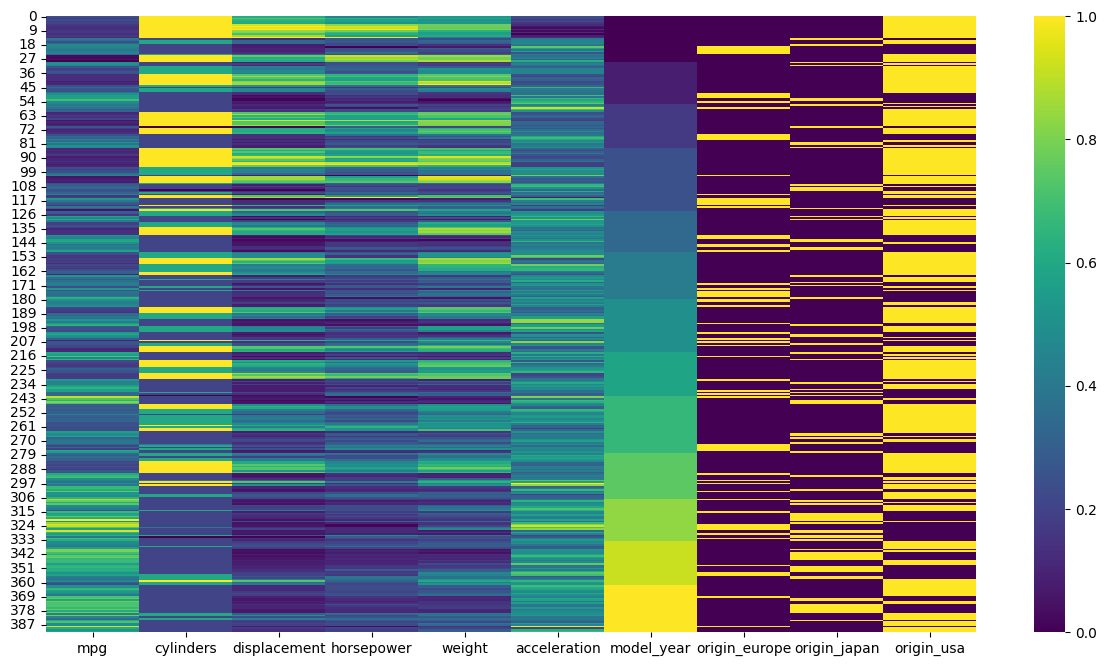

In [18]:
plt.figure(figsize=(15,8))
sns.heatmap(scaled_df,cmap='viridis')

You can see in the heatmap the range of the different features. You can clearly see that the observations are neatly ordered by year; the last three features are either 0 or 1, because they are the origin dummy variables and behave as booleans; and some of the other features take a turn in color as the years pass, showing a trend in all makers from one end of the range towards the other end (like displacement or horsepower being in decline, while mileage increases).

<Figure size 1500x800 with 0 Axes>

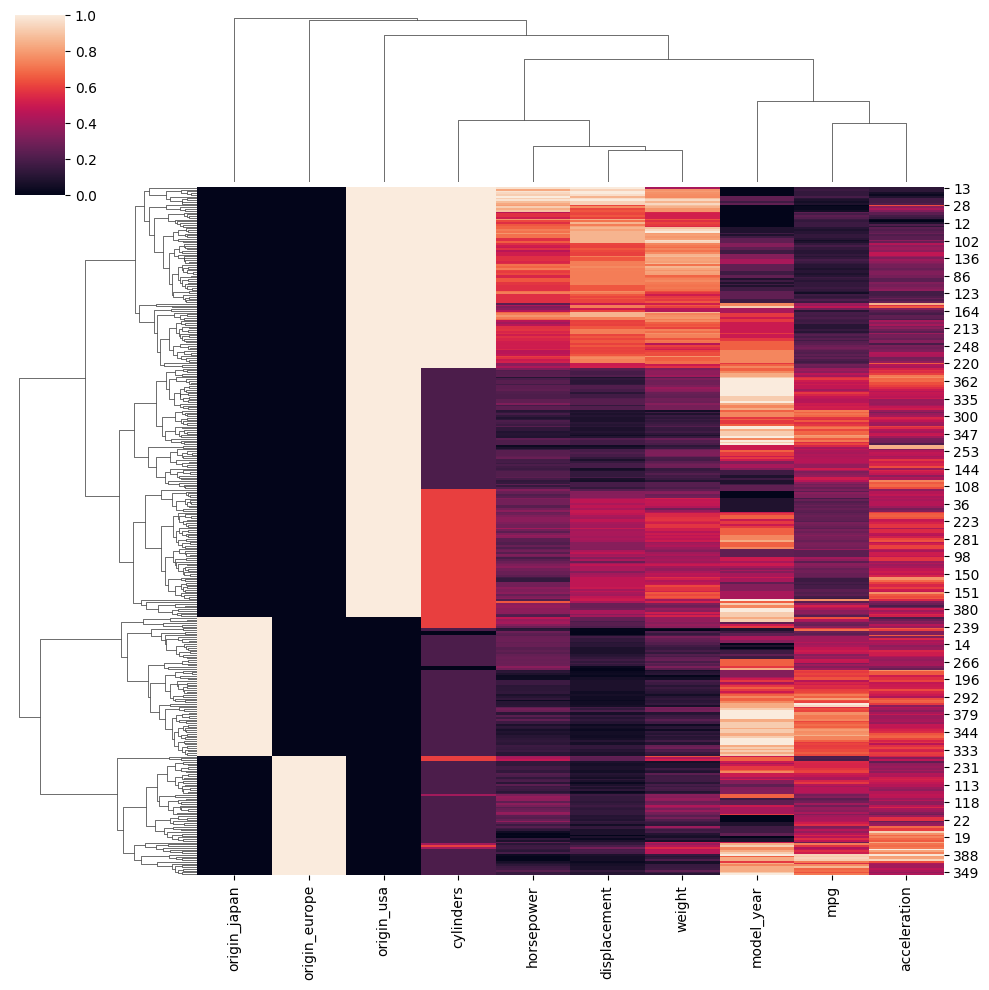

In [19]:
plt.figure(figsize=(15,8))
sns.clustermap(scaled_df)

The clustering of features just represents which features are related to each other, and that is correlation; for that purpose we have .corr() which is more appropriate and economic.

The intended clustering is grouping of observations, clustering of rows. And since dummy variables are 0-1, they are deem to be the ones having the biggest distances. So you may want evaluate wether you want to use them for the clustering or not. Let's see what the clustering looks like when removing them.

<Figure size 1500x800 with 0 Axes>

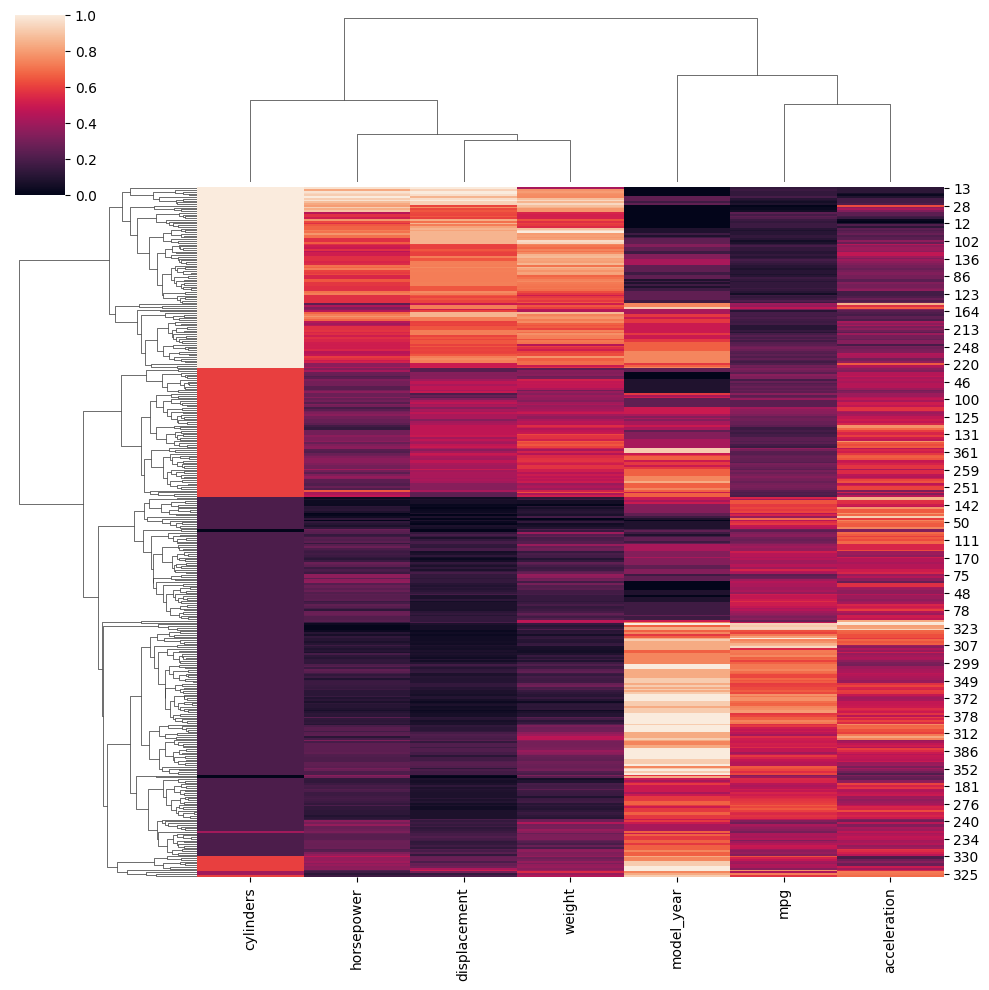

In [21]:
plt.figure(figsize=(15,8))
sns.clustermap(scaled_df.drop(['origin_japan','origin_europe','origin_usa'],axis=1))

And look at what looks like the clustering of features only, without the dummy variables.

<Figure size 1500x800 with 0 Axes>

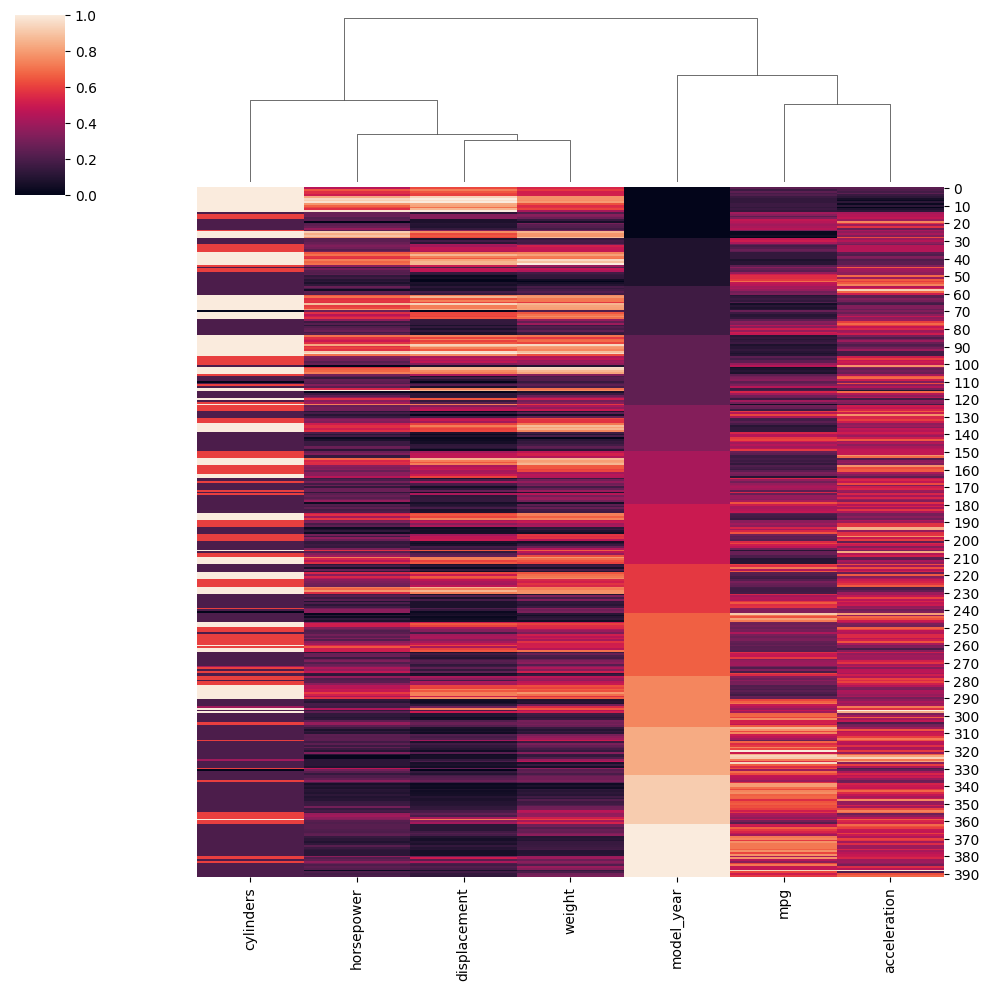

In [22]:
plt.figure(figsize=(15,8))
sns.clustermap(scaled_df.drop(['origin_japan','origin_europe','origin_usa'],axis=1), row_cluster=False)

What was said about correlation showing how similar features are, can be seen in a correlation heatmap, that shows high correlation among fetures that are similar.

<Axes: >

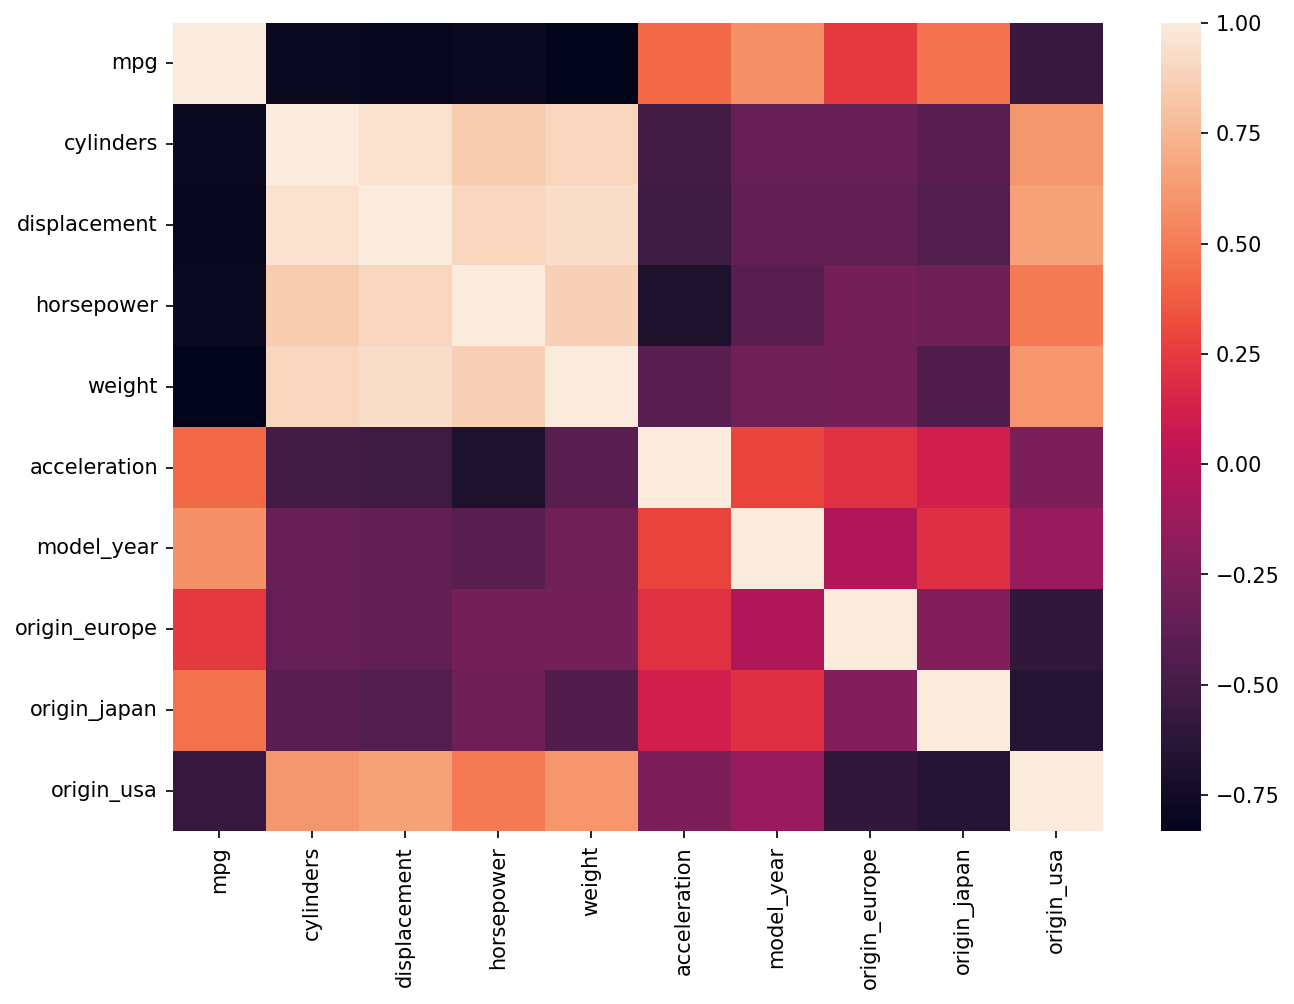

In [27]:
plt.figure(figsize=(10,7),dpi=150)
sns.heatmap(scaled_df.corr())

The true clustering purpose is when taking into account only rows, no feature clustering.

<Figure size 2250x1200 with 0 Axes>

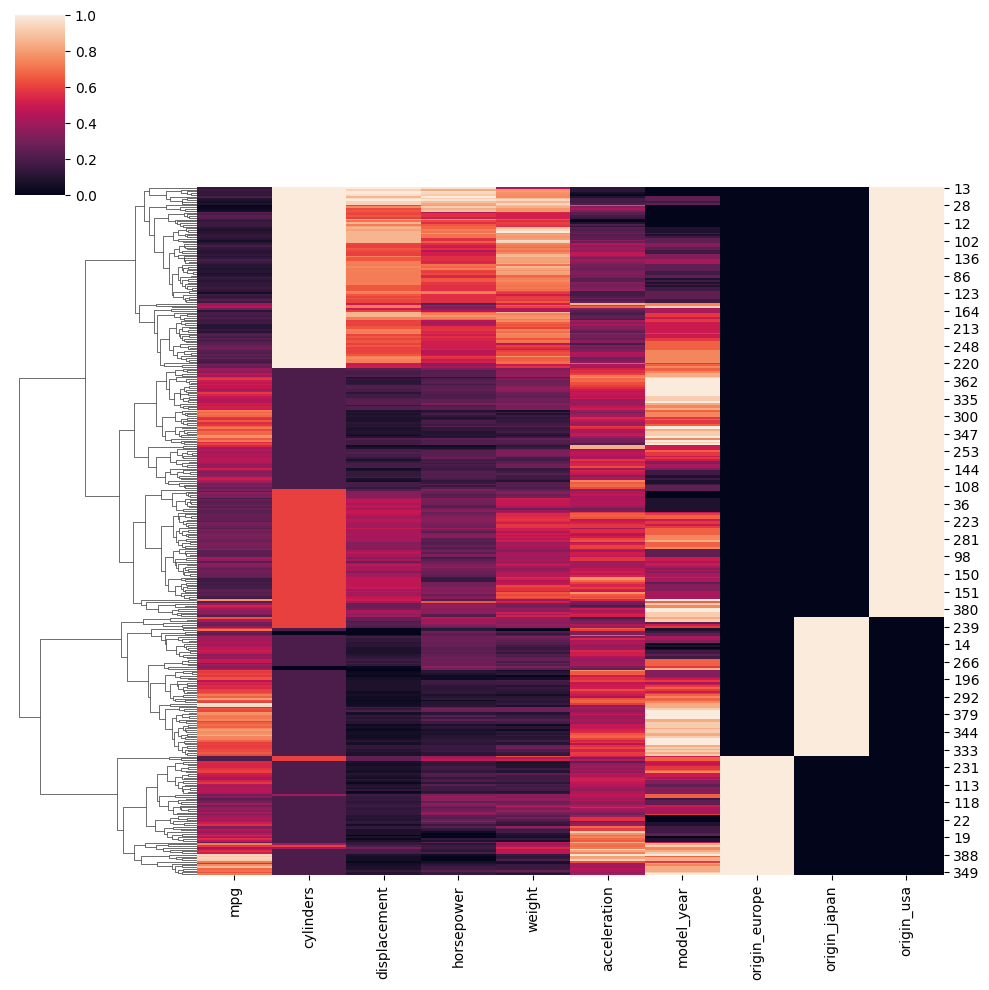

In [28]:
plt.figure(figsize=(15,8),dpi=150)
sns.clustermap(scaled_df,col_cluster=False)

In [37]:
from sklearn.cluster import AgglomerativeClustering

In [41]:
model=AgglomerativeClustering(n_clusters=4)

In [42]:
cluster_labels=model.fit_predict(scaled_df)
cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 3, 2, 2, 2,
       2, 2, 0, 1, 1, 1, 1, 3, 0, 3, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 2, 0, 3, 0, 2, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 2, 2, 0, 3, 3, 0, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 3, 0, 3,
       3, 0, 0, 2, 1, 1, 2, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 3, 0, 3, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 0, 2, 2, 3, 3, 2, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 3, 0, 0, 0, 3, 2, 3, 0, 2, 0, 2,
       2, 2, 2, 3, 2, 2, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 3, 0,
       0, 0, 0, 2, 3, 3, 0, 2, 1, 2, 3, 2, 1, 1, 1, 1, 3, 0, 2, 0, 3, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 3, 0, 0, 0, 3, 2, 3, 2, 3,
       2, 0, 3, 3, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 3, 3, 0, 3, 0, 0, 3, 2, 2, 2, 2, 2, 3, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 3, 0, 0, 2, 1, 2, 1, 0, 0,

You can represent the cluster labels the model returned against the original dataframe (indices are the same as used to find out the labels with scaled_df)

<Axes: xlabel='mpg', ylabel='weight'>

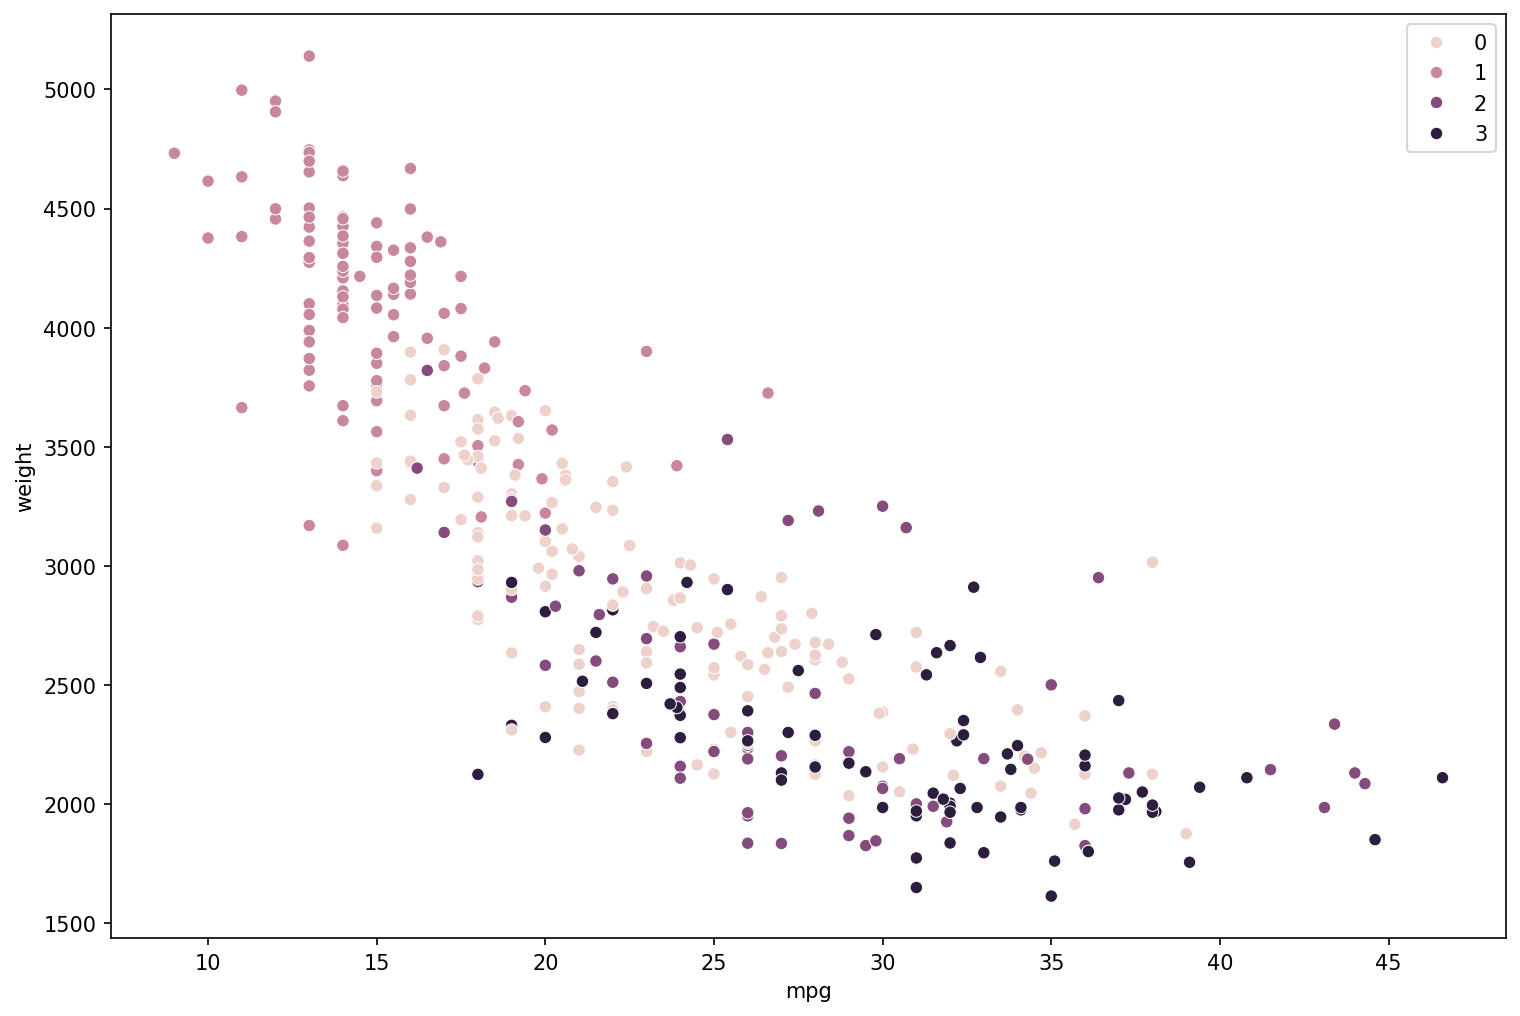

In [44]:
plt.figure(figsize=(12,8),dpi=150)
sns.scatterplot(data=df,x='mpg',y='weight',hue=cluster_labels)

<Axes: xlabel='mpg', ylabel='horsepower'>

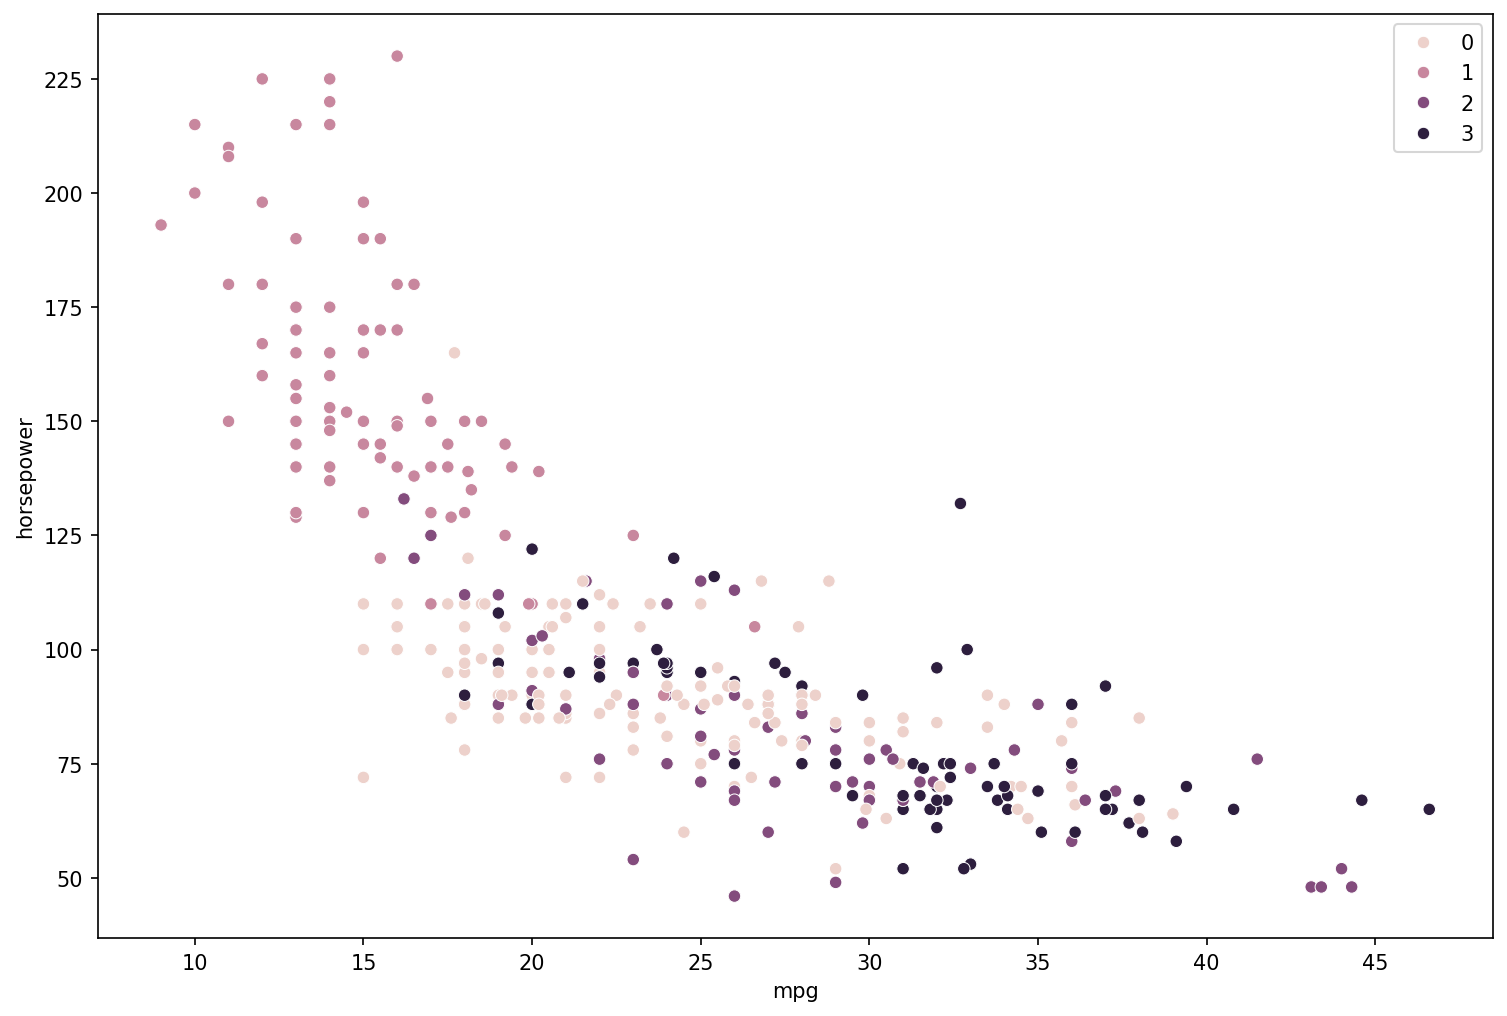

In [45]:
plt.figure(figsize=(12,8),dpi=150)
sns.scatterplot(data=df,x='mpg',y='horsepower',hue=cluster_labels)

<Axes: xlabel='horsepower', ylabel='origin'>

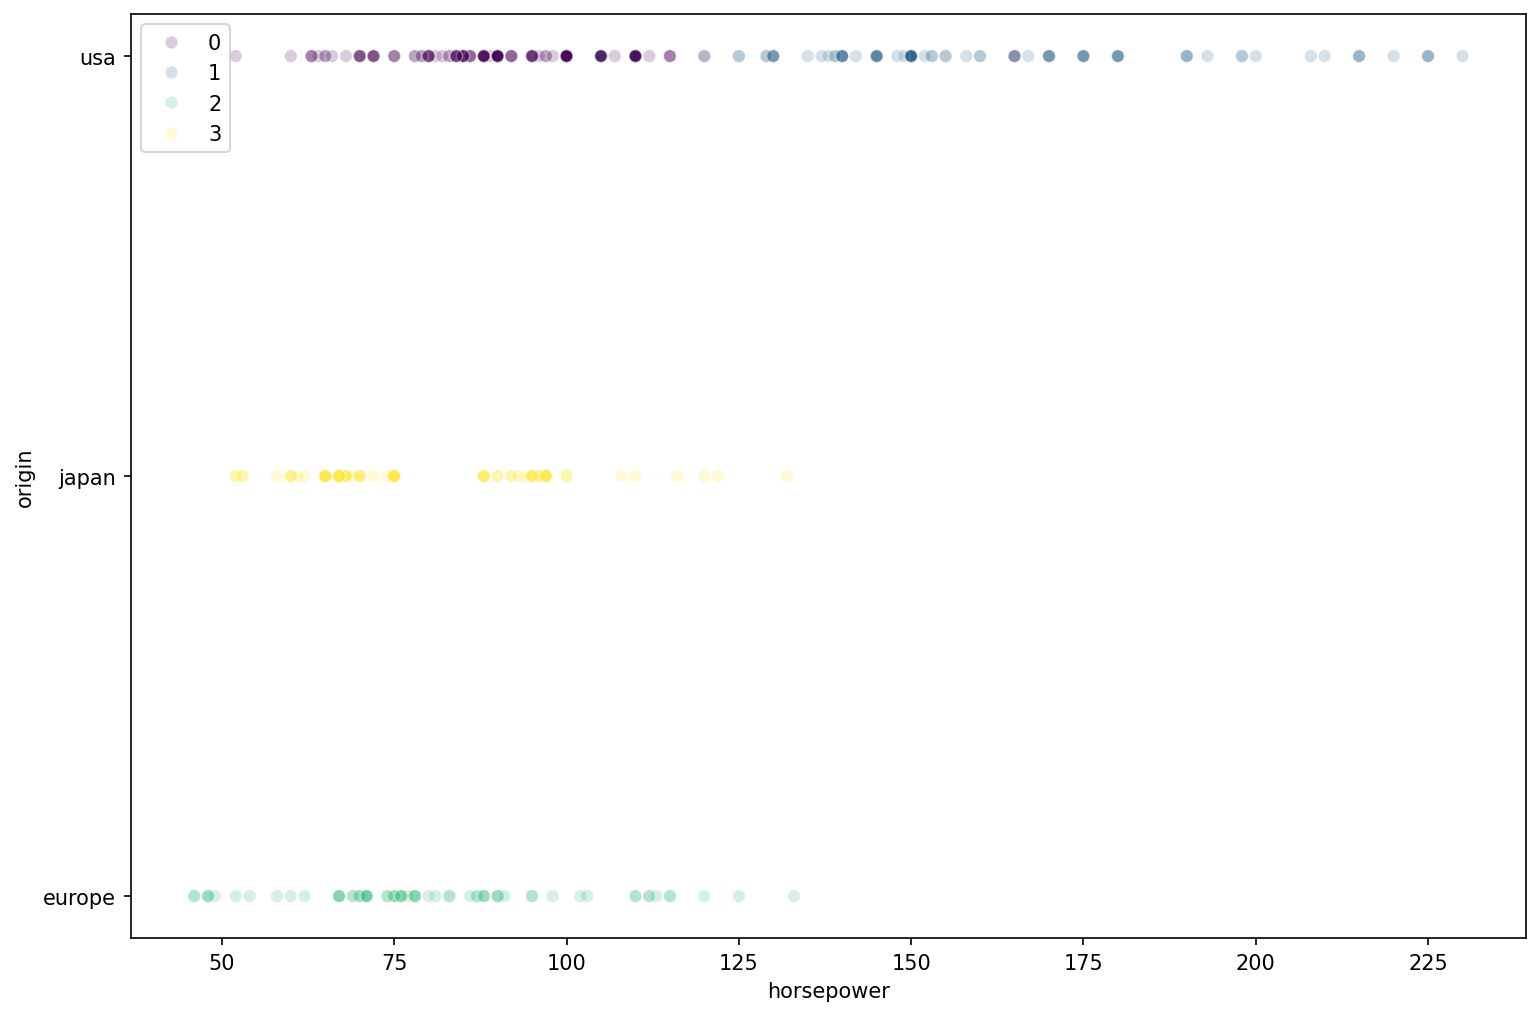

In [60]:
plt.figure(figsize=(12,8),dpi=150)
sns.scatterplot(data=df,x='horsepower',y='origin',hue=cluster_labels,palette='viridis',alpha=0.2)

Knowing that we are using euclidean distance as method to calculate the distance between 2 points, and that the maximum distance between two points is sqrt(number of features); we have 10 features, so our maximum distance is sqrt(10).

This can be used as a parameter for AgglomerativeClustering.

In [62]:
# do not merge points together, have points separated if their distance is 0 or greter
model=AgglomerativeClustering(n_clusters=None,distance_threshold=0)

In [63]:
cluster_labels=model.fit_predict(scaled_df)
cluster_labels

array([247, 252, 360, 302, 326, 381, 384, 338, 300, 279, 217, 311, 377,
       281, 232, 334, 272, 375, 354, 333, 317, 345, 329, 289, 305, 383,
       290, 205, 355, 269, 202, 144, 245, 297, 386, 358, 199, 337, 330,
       339, 293, 352, 283, 196, 253, 168, 378, 331, 201, 268, 256, 361,
       250, 197, 246, 371, 324, 230, 203, 261, 380, 376, 308, 389, 332,
       306, 236, 391, 350, 274, 288, 313, 231, 298, 100, 295, 210, 248,
       187, 390, 373, 266, 307, 379, 212, 357, 191, 314, 208, 249, 343,
       294, 374, 322, 323, 362, 188, 296, 369, 286, 251, 229, 244, 285,
       349, 365, 259, 213, 276, 215, 222, 204, 359, 287, 166, 387, 291,
       220, 216, 260, 129, 367, 340, 346, 301, 342, 228, 388, 370, 218,
       255, 327, 347, 278, 271, 258, 282, 318, 273, 123, 172, 382, 363,
       356, 195, 280, 239, 364, 267, 351, 186, 257, 277, 299, 127, 366,
       234, 385, 192, 372, 292, 233, 270, 263, 133, 165, 161, 198,  97,
       315, 134, 207, 147, 175, 262, 348,  98, 214,  48, 353, 17

In [68]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [69]:
linkage_matrix=linkage(model.children_)
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]],
      shape=(390, 4))

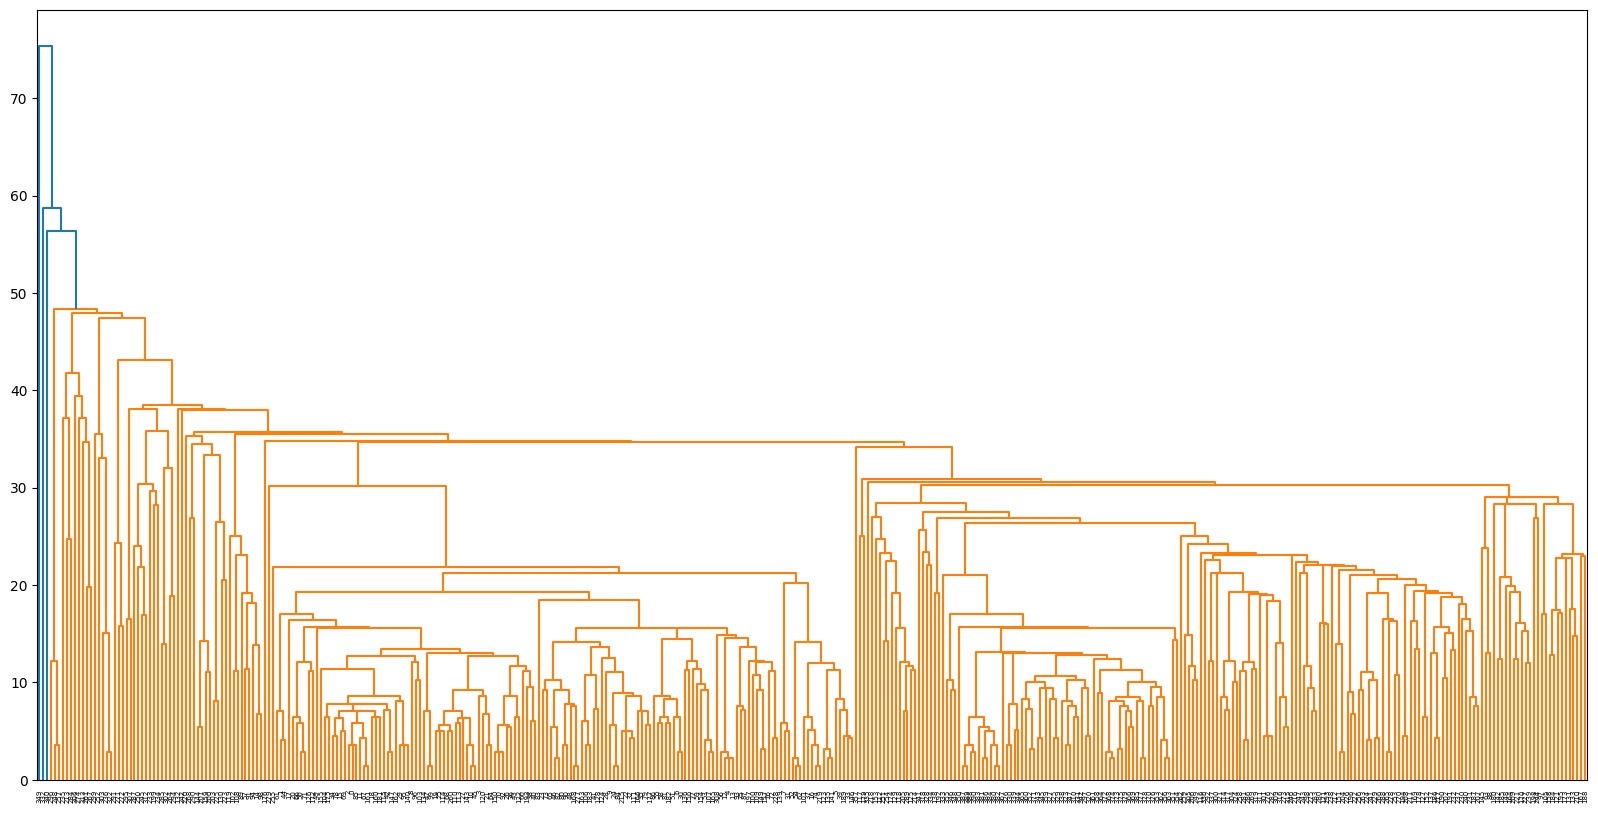

In [70]:
plt.figure(figsize=(20,10))
dendro = dendrogram(linkage_matrix)

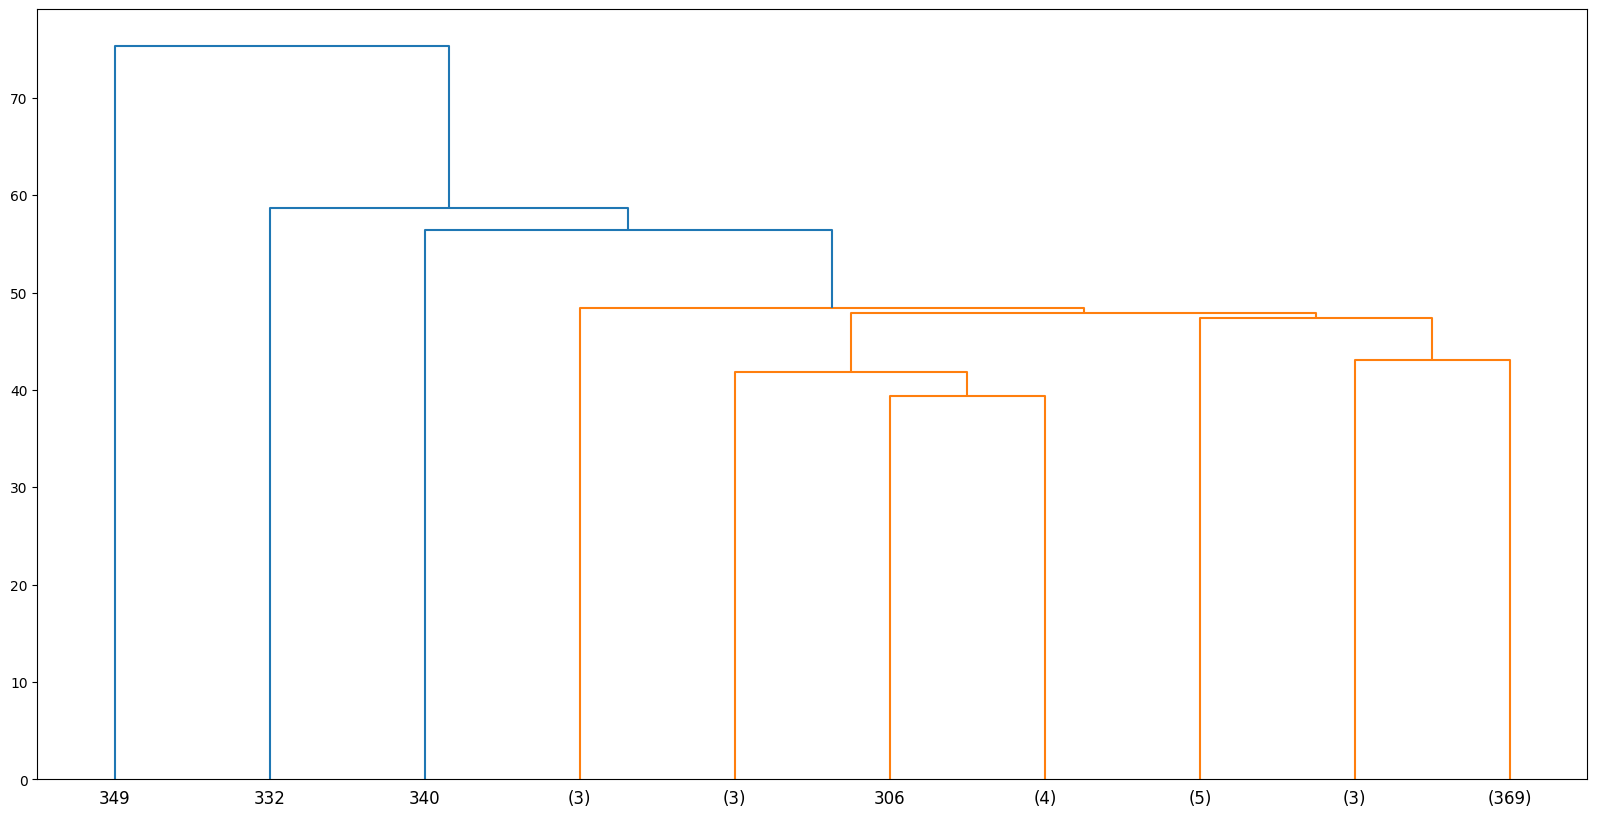

In [71]:
# Can be used to infer the approximate number of clusters that better fit our data.
plt.figure(figsize=(20,10))
dendro = dendrogram(linkage_matrix,truncate_mode='lastp',p=10)

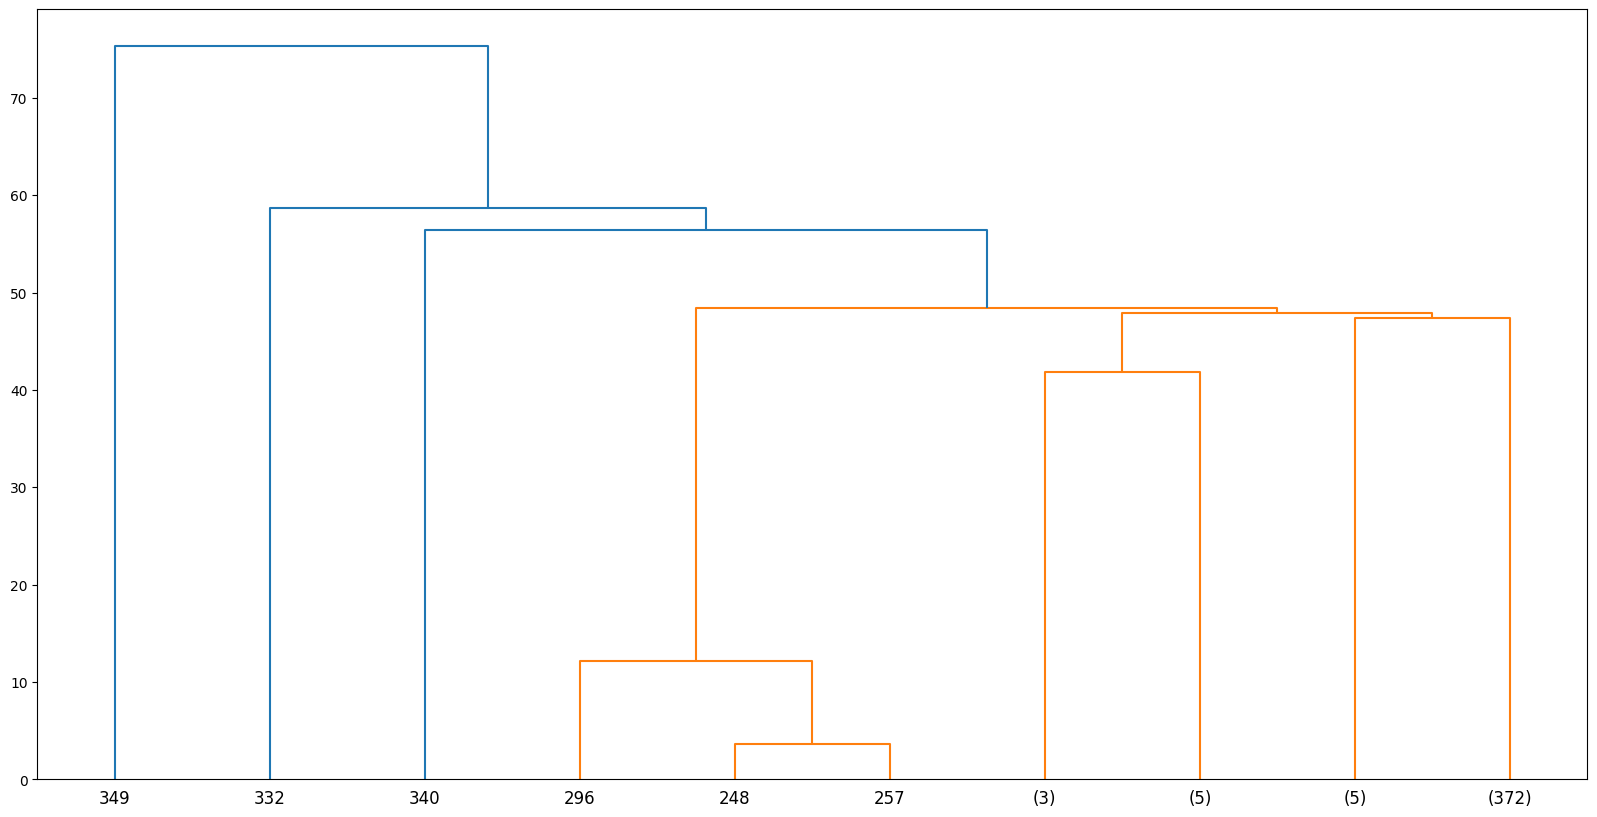

In [72]:
plt.figure(figsize=(20,10))
dendro = dendrogram(linkage_matrix,truncate_mode='level',p=5)

In [73]:
# maximum theoretical distance:
np.sqrt(len(scaled_df.columns))

np.float64(3.1622776601683795)

In [ ]:
#Actual distance of max and min mpg values.

In [75]:
scaled_df[scaled_df['mpg']==scaled_df['mpg'].max()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
320,1.0,0.2,0.046512,0.103261,0.140913,0.589286,0.833333,0.0,1.0,0.0


In [76]:
scaled_df[scaled_df['mpg']==scaled_df['mpg'].min()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
28,0.0,1.0,0.609819,0.798913,0.884321,0.625,0.0,0.0,0.0,1.0


In [77]:
car_a=scaled_df.iloc[320]
car_b=scaled_df.iloc[28]
distance=np.linalg.norm(car_a-car_b)

In [78]:
distance

np.float64(2.3852929970374714)

now we can use some value like '2' as an initial value for distance_threshold and see how many clusters we get.

In [79]:
model=AgglomerativeClustering(n_clusters=None,distance_threshold=2)

In [80]:
cluster_labels=model.fit_predict(scaled_df)
cluster_labels

array([ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  1,  4,  4,
        4,  1,  0,  0,  0,  0,  0,  4,  3,  3,  3,  3,  1,  7,  1,  4,  4,
        4,  4,  4,  3,  3,  3,  3,  3,  3,  3,  4,  7,  4,  4,  7,  0,  0,
        0,  1,  1,  0,  7,  1,  7,  0,  7,  7,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  1,  3,  3,  3,  3,  0,  0,  0,  0,  7,  1,  1,  7,  1,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  0,
        3,  3,  3,  3,  4,  1,  7,  1,  1,  7,  4,  0,  3,  3,  0,  0,  0,
        0,  3,  0, 10,  3,  4,  4,  4,  1,  7,  1,  7,  4,  4,  4,  3,  3,
        3,  3,  3,  0,  0,  0,  1,  1,  7,  0,  0,  1,  1,  0,  4,  4,  4,
        4,  5,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  1,  7,  4,  7,  1,
        0,  1,  4,  0,  4,  0,  0,  0,  0,  1,  0,  0,  7,  7,  0,  5,  5,
        5,  5,  4,  4,  4,  4,  7,  7,  0,  1,  9,  4,  9,  4,  0,  1,  1,
        7,  0,  5,  8, 10,  0,  5,  5,  5,  5,  1,  2,  8,  7,  1,  5,  5,
        5,  5,  9,  9,  9

So there are 11 clusters.

We can go back to the dendrogram and set p=11

In [81]:
linkage_matrix=linkage(model.children_)
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]],
      shape=(390, 4))

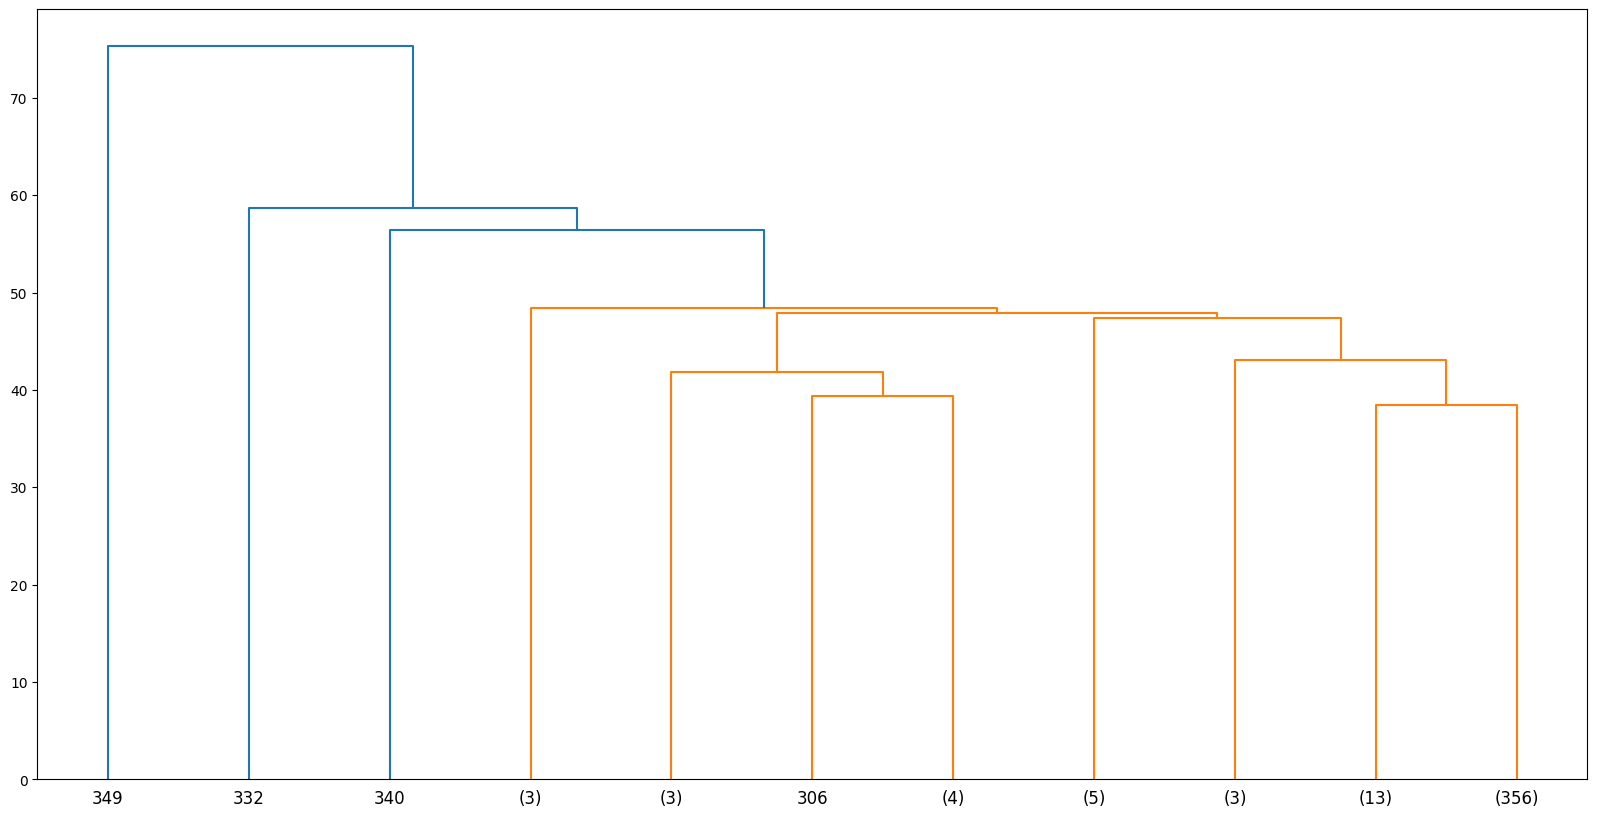

In [83]:
plt.figure(figsize=(20,10))
dendro = dendrogram(linkage_matrix,truncate_mode='lastp',p=11)

You can also go directly with the number of clusters in the model now

In [86]:
model=AgglomerativeClustering(n_clusters=11)
cluster_labels=model.fit_predict(scaled_df)

<Axes: xlabel='cylinders', ylabel='displacement'>

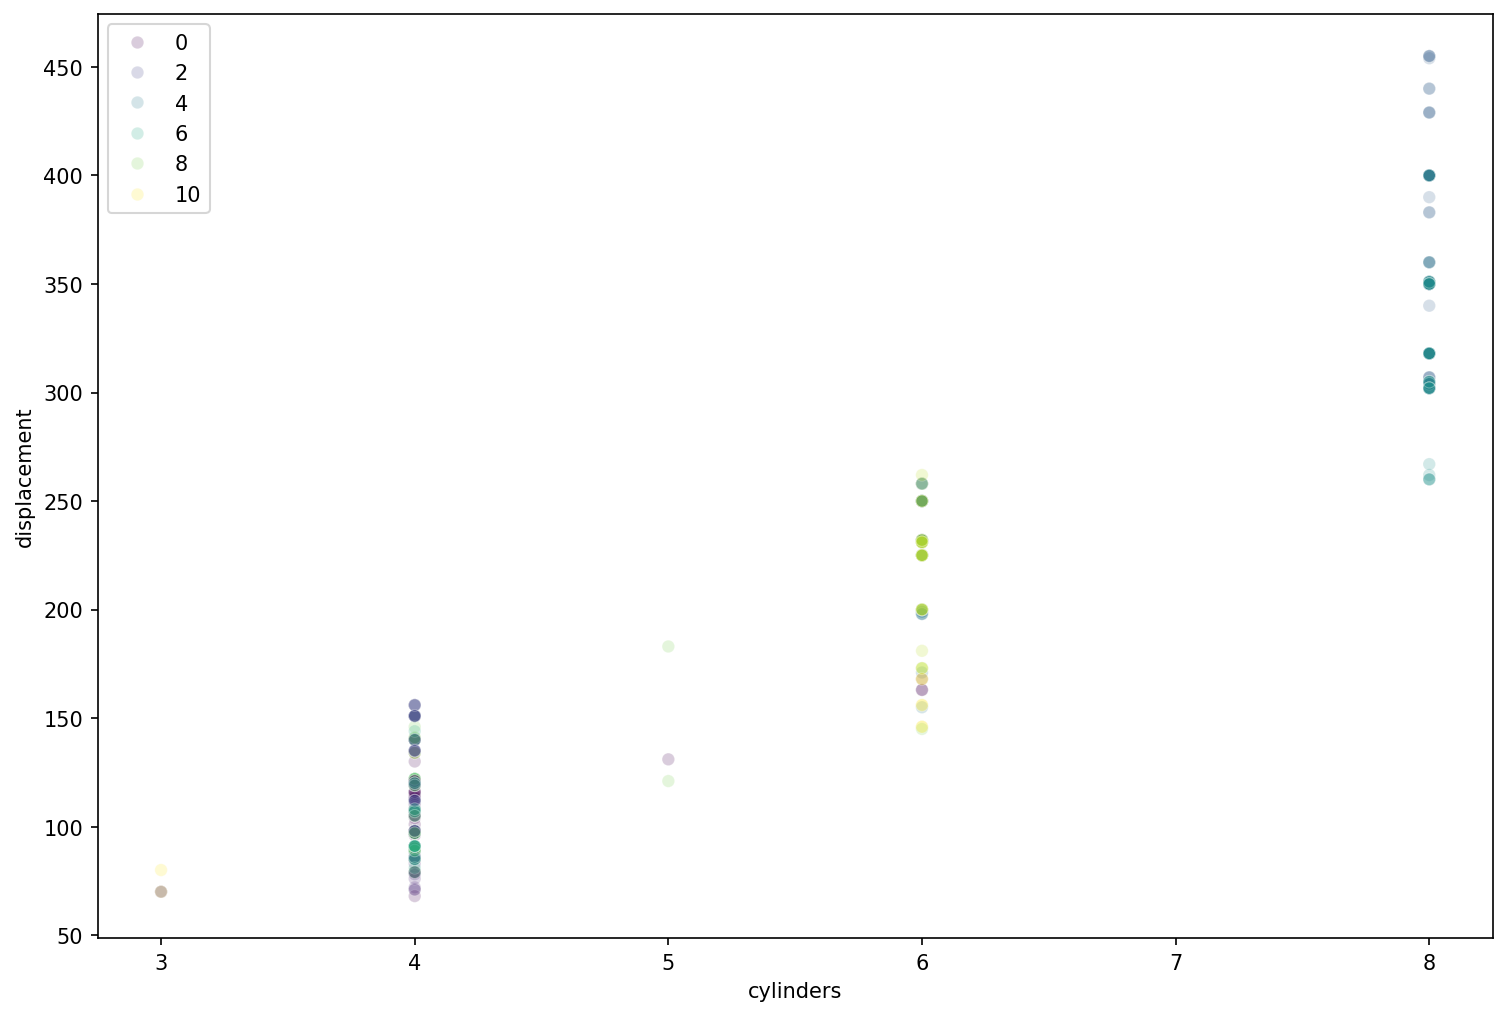

In [96]:
plt.figure(figsize=(12,8),dpi=150)
sns.scatterplot(data=df,x='cylinders',y='displacement',hue=cluster_labels,palette='viridis',alpha=0.2)